# OptiCore Tutorial — Real Options Data with Yahoo Finance

**For new users.** This notebook walks through every Phase 1 feature of OptiCore using **free, no-account data** from Yahoo Finance. By the end you'll have:

1. Fetched a real options chain for a US equity
2. Computed implied volatility for every contract
3. Computed all five Greeks (delta, gamma, theta, vega, rho)
4. Plotted the volatility smile
5. Built and visualized a vertical-spread payoff
6. Inspected how Greeks change with spot price

**Time:** ~10 minutes.

**Prerequisites:**
```bash
pip install opticore[data-yfinance,viz]
```

If you want IBKR data instead of Yahoo, see `02_ibkr_setup.ipynb`. Yahoo is faster to get going (no account, no subscription) but its quotes are 15-min delayed and can be flaky outside market hours.

## 0. Setup — verify the install

In [3]:
!pip install opticore[data-yfinance,viz]

zsh:1: no matches found: opticore[data-yfinance,viz]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import opticore as oc

print(f"OptiCore version: {oc.__version__}")
print(f"Public API: {[n for n in oc.__all__ if not n.startswith('_')]}")

OptiCore version: 0.2.0
Public API: ['price', 'iv', 'greeks', 'greeks_table', 'fetch_chain', 'enrich', 'check_connection', 'GreeksResult', 'Leg', 'plot']


## 1. Fetch a real options chain

`oc.fetch_chain(symbol, provider="yfinance")` pulls a delayed chain from Yahoo Finance. No API key, no broker.

**Parameters:**
- `symbol` — any optionable US equity (try `"SPY"`, `"AAPL"`, `"MSFT"`, `"QQQ"`)
- `max_expiries` — number of nearest expiries to fetch (more = slower)
- `strike_count` — strikes around ATM on each side. 10 = 21 strikes per expiry per side

We'll start with **SPY** (most liquid US options market — best for a first run).

In [2]:
chain = oc.fetch_chain(
    "SPY",
    provider="yfinance",
    max_expiries=4,
    strike_count=10,
)

print(f"Fetched {len(chain)} rows")
print(f"Underlying spot: ${chain['underlying_price'].iloc[0]:.2f}")
print(f"Expiries: {sorted(chain['expiry'].unique())}")
chain.head(8)

Fetched 155 option contracts for SPY (4 expiries) from yfinance
Fetched 155 rows
Underlying spot: $723.47
Expiries: ['20260501', '20260504', '20260505', '20260506']


,symbol,strike,expiry,kind,bid,ask,last,volume,open_interest,underlying_price,mid
0,SPY,713.0,20260501,call,10.36,10.44,10.16,6700,2767,723.465027,10.400
1,SPY,714.0,20260501,call,9.36,9.44,9.27,8651,4337,723.465027,9.400
2,SPY,715.0,20260501,call,8.34,8.42,8.40,11070,15333,723.465027,8.380
3,SPY,716.0,20260501,call,7.34,7.47,7.28,8660,7335,723.465027,7.405
4,SPY,717.0,20260501,call,6.37,6.45,6.40,8579,7371,723.465027,6.410
5,SPY,718.0,20260501,call,5.37,5.40,5.38,8738,7820,723.465027,5.385
6,SPY,719.0,20260501,call,4.44,4.47,4.47,12858,8083,723.465027,4.455
7,SPY,720.0,20260501,call,3.54,3.57,3.53,35051,17237,723.465027,3.555


**What's in the chain DataFrame:**

| Column | Meaning |
|---|---|
| `symbol` | Underlying ticker |
| `strike` | Option strike price |
| `expiry` | Expiration date as `YYYYMMDD` |
| `kind` | `"call"` or `"put"` |
| `bid`, `ask`, `last` | Quote fields (NaN if missing) |
| `mid` | `(bid + ask) / 2`, falling back to `last` if no quotes |
| `volume`, `open_interest` | Liquidity indicators |
| `underlying_price` | Spot price of the underlying at fetch time |

The exact same schema comes back from `provider="ibkr"` — every downstream function works either way.

## 2. Enrich — add IV and Greeks

The chain has prices but no IV or Greeks. `oc.enrich()` adds them, computing:

- `iv` — implied volatility solved from `mid` price (Jaeckel's algorithm — full machine precision)
- `delta`, `gamma`, `theta`, `vega`, `rho` — all five first-order Greeks
- `tte` — time to expiry in years
- `moneyness` — `strike / underlying`
- `intrinsic` — intrinsic value (`max(S - K, 0)` for calls, etc.)
- `model_price` — BSM price using the solved IV (sanity check vs `mid`)

In [3]:
# rate = current short-term Treasury rate. Tweak as needed.
enriched = oc.enrich(chain, rate=0.045, div_yield=0.0)

# Show the most interesting columns
cols = ["strike", "expiry", "kind", "mid", "iv", "delta", "gamma", "theta", "vega"]
enriched[cols].head(10)

Enriched 136 options, 19 IV failures (12.3%)


,strike,expiry,kind,mid,iv,delta,gamma,theta,vega
0,713.0,20260501,call,10.400,NaN,NaN,NaN,NaN,NaN
1,714.0,20260501,call,9.400,NaN,NaN,NaN,NaN,NaN
2,715.0,20260501,call,8.380,NaN,NaN,NaN,NaN,NaN
3,716.0,20260501,call,7.405,NaN,NaN,NaN,NaN,NaN
4,717.0,20260501,call,6.410,NaN,NaN,NaN,NaN,NaN
5,718.0,20260501,call,5.385,NaN,NaN,NaN,NaN,NaN
6,719.0,20260501,call,4.455,NaN,NaN,NaN,NaN,NaN
7,720.0,20260501,call,3.555,3.421762,0.919960,0.060077,-504.420152,0.001076
8,721.0,20260501,call,2.645,3.264217,0.852507,0.097625,-745.893325,0.001668
9,722.0,20260501,call,1.840,3.223899,0.735780,0.140223,-1045.011790,0.002366


**Reading the output:** the IV-failure message tells you how many contracts couldn't have a valid IV solved (no quote, deep ITM, etc.). 5–25% failures on a real chain is normal — those are typically illiquid strikes with 0 bid or stale `last`.

Let's confirm the model is internally consistent — `mid` should match `model_price` to within rounding.

In [4]:
valid = enriched.dropna(subset=["iv", "model_price"])
diff = (valid["mid"] - valid["model_price"]).abs().max()
print(f"Max |mid − model_price| over {len(valid)} contracts: {diff:.2e}")
print("(Should be ~1e-10 — round-trip precision)")

Max |mid − model_price| over 136 contracts: 2.13e-13
(Should be ~1e-10 — round-trip precision)


## 3. Plot the volatility smile

Plot IV against strike for the nearest expiry. In a Black-Scholes world IV would be flat — in reality OTM puts trade rich (smile / skew) because the market prices in tail risk.

`oc.plot.smile()` does this in one call.

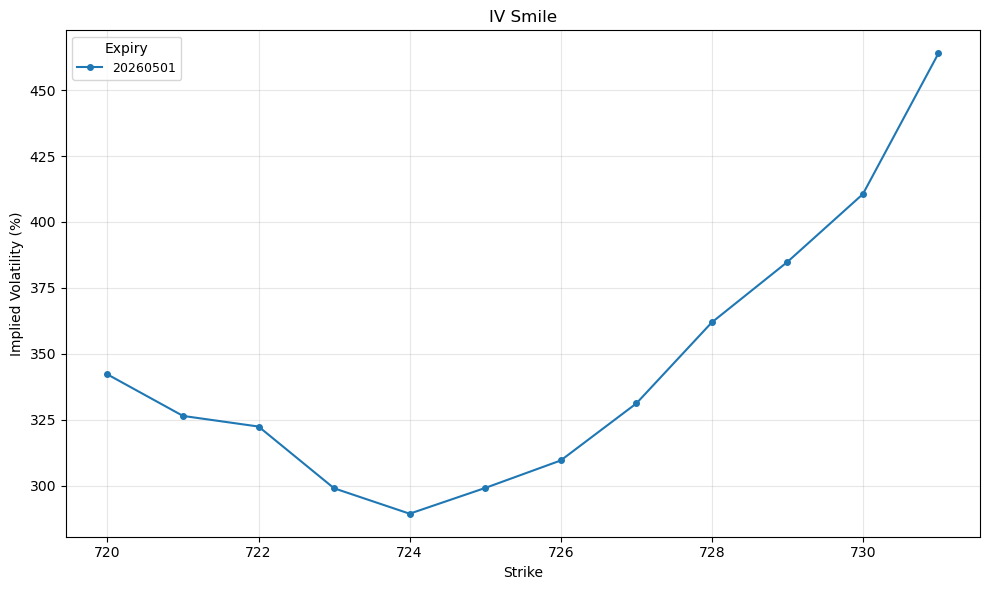

In [5]:
# Pick the nearest expiry
nearest = sorted(enriched["expiry"].unique())[0]
near_chain = enriched[enriched["expiry"] == nearest]

fig = oc.plot.smile(near_chain, expiry=nearest)
plt.show()


**What you should see:** a U-shape (volatility smile) or a left-leaning skew. ATM IV is the reference; OTM puts (low strikes) typically have higher IV than OTM calls (high strikes) for index ETFs like SPY.

## 4. Build a strategy — vertical call spread

A **bull call spread**: long an ATM call, short a higher-strike call. Capped upside, capped loss.

`oc.Leg(kind, strike, qty, premium)` — `qty>0` = long, `qty<0` = short.

In [6]:
spot = chain["underlying_price"].iloc[0]

# Pick two real strikes from the chain — closest to ATM and the next strike up
calls_near = (
    near_chain[near_chain["kind"] == "call"]
    .dropna(subset=["mid"])
    .query("mid > 0")
    .sort_values("strike")
    .reset_index(drop=True)
)
atm_idx = (calls_near["strike"] - spot).abs().idxmin()
# Step ~3 strikes higher for a meaningful spread; clamp to the last available
otm_idx = min(atm_idx + 3, len(calls_near) - 1)

atm_strike = float(calls_near.loc[atm_idx, "strike"])
otm_strike = float(calls_near.loc[otm_idx, "strike"])
atm_premium = float(calls_near.loc[atm_idx, "mid"])
otm_premium = float(calls_near.loc[otm_idx, "mid"])

legs = [
    oc.Leg(kind="call", strike=atm_strike, qty=+1, premium=atm_premium),
    oc.Leg(kind="call", strike=otm_strike, qty=-1, premium=otm_premium),
]

net_debit = atm_premium - otm_premium
max_profit = (otm_strike - atm_strike) - net_debit

print(f"Long  {atm_strike:.0f} call @ ${atm_premium:.2f}")
print(f"Short {otm_strike:.0f} call @ ${otm_premium:.2f}")
print(f"Net debit:   ${net_debit:.2f}")
print(f"Max profit:  ${max_profit:.2f}  (at spot >= {otm_strike:.0f} at expiry)")
print(f"Max loss:    ${net_debit:.2f}  (at spot <= {atm_strike:.0f} at expiry)")
print(f"Breakeven:   {atm_strike + net_debit:.2f}")


Long  723 call @ $1.12
Short 726 call @ $0.15
Net debit:   $0.97
Max profit:  $2.03  (at spot >= 726 at expiry)
Max loss:    $0.97  (at spot <= 723 at expiry)
Breakeven:   723.97


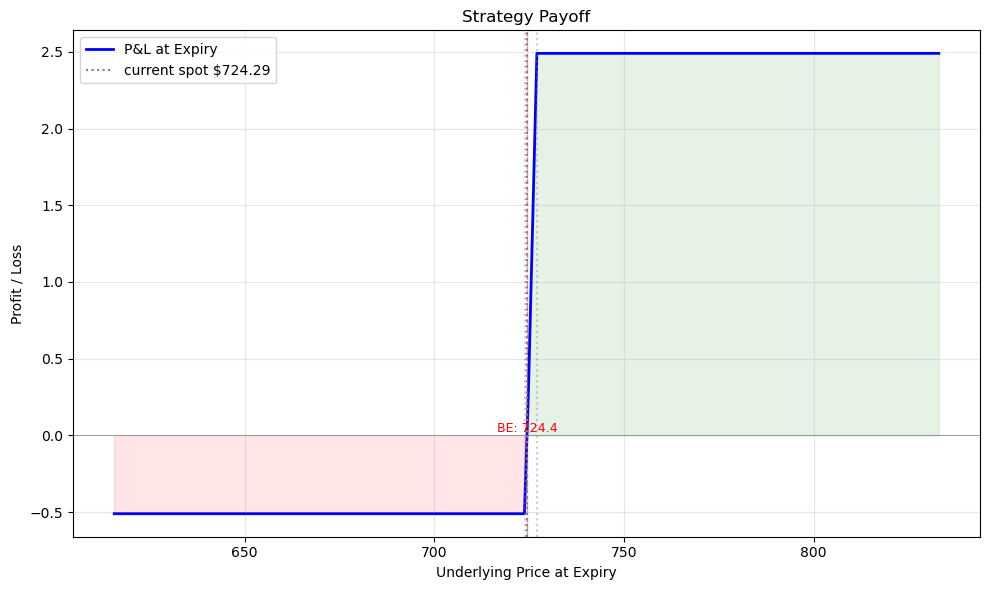

In [7]:
# Create our own figure so we can add a 'current spot' line
fig, ax = plt.subplots(figsize=(10, 6))
oc.plot.payoff(legs, spot_range=(spot * 0.85, spot * 1.15), ax=ax)
ax.axvline(spot, color="gray", linestyle=":", label=f"current spot ${spot:.2f}")
ax.legend()
plt.show()


## 5. Greeks across spot — what happens if SPY moves?

`oc.plot.greek()` shows how a single Greek changes as the underlying moves. Useful for understanding risk concentration.

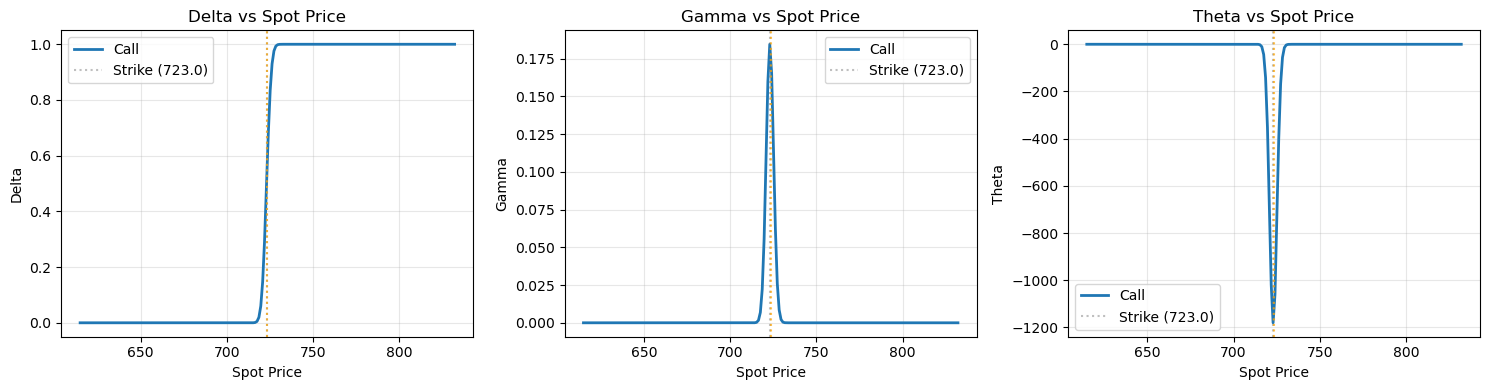

In [7]:
# Use the ATM call we just analyzed
tte_years = enriched.loc[enriched["strike"] == atm_strike, "tte"].iloc[0]
atm_iv = enriched.loc[enriched["strike"] == atm_strike, "iv"].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, greek_name in zip(axes, ["delta", "gamma", "theta"]):
    oc.plot.greek(
        greek_name,
        spot_range=(spot * 0.85, spot * 1.15),
        strike=atm_strike,
        expiry=tte_years,
        rate=0.045,
        vol=atm_iv,
        kind="call",
        ax=ax,
    )
    ax.axvline(spot, color="orange", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()


**What to notice:**
- **Delta** is sigmoid: ~0 deep OTM, ~0.5 ATM, ~1 deep ITM
- **Gamma** peaks at ATM and decays in both directions — gamma risk is concentrated near the strike
- **Theta** is most negative ATM near expiry (this is why selling ATM-near-expiry is a popular income strategy)

## 6. Compare two expiries — term structure of IV

Plot ATM IV across the expiries we fetched. Normally the curve is upward-sloping (longer-dated options have higher IV); when it inverts, the market expects a near-term volatility event.

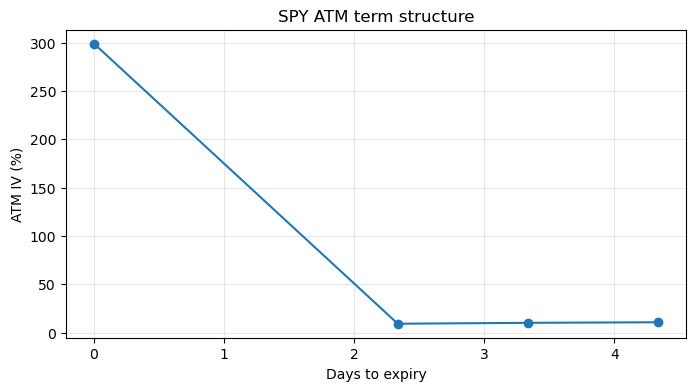

,expiry,strike,iv,tte
0,20260501,723.0,2.989639,0.000001
1,20260504,723.0,0.092380,0.006397
2,20260505,725.0,0.101605,0.009135
3,20260506,725.0,0.107484,0.011873


In [8]:
# For each expiry, find the IV closest to ATM
term = (
    enriched.dropna(subset=["iv"])
    .assign(dist=lambda d: (d["strike"] - d["underlying_price"]).abs())
    .sort_values(["expiry", "dist"])
    .groupby("expiry")
    .first()
    [["strike", "iv", "tte"]]
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(term["tte"] * 365, term["iv"] * 100, marker="o")
ax.set_xlabel("Days to expiry")
ax.set_ylabel("ATM IV (%)")
ax.set_title(f"{chain['symbol'].iloc[0]} ATM term structure")
ax.grid(alpha=0.3)
plt.show()

term

## 7. Direct API — pricing without a chain

Everything above used real market data. But OptiCore's pricing API is independent — useful for hypotheticals, backtests, or just learning. The same functions work scalar or vectorized.

**Scalar:**

In [9]:
# Price one contract
p = oc.price(spot=100, strike=105, expiry=0.5, rate=0.05, vol=0.20, kind="call")
print(f"Call price: ${p:.4f}")

# Solve IV from a market price
iv = oc.iv(price=p, spot=100, strike=105, expiry=0.5, rate=0.05, kind="call")
print(f"Implied vol: {iv:.6f}")

# All Greeks at once
g = oc.greeks(spot=100, strike=105, expiry=0.5, rate=0.05, vol=0.20, kind="call")
print(f"Delta={g.delta:.4f}  Gamma={g.gamma:.6f}  Theta={g.theta:.4f}")
print(f"Vega ={g.vega:.4f}   Rho  ={g.rho:.6f}")

Call price: $4.5817
Implied vol: 0.200000
Delta=0.4612  Gamma=0.028076  Theta=-0.0211
Vega =0.2808   Rho  =0.207672


**Vectorized — price an entire strike ladder in one call:**

In [10]:
strikes = np.arange(80, 121, dtype=float)
prices = oc.price(
    spot=100, strike=strikes, expiry=0.5, rate=0.05, vol=0.20, kind="call"
)

# Or get a Greeks table directly as a DataFrame
table = oc.greeks_table(
    spot=100, strike=strikes, expiry=0.5, rate=0.05, vol=0.20, kind="call"
)
table.head(10)

,strike,expiry,price,delta,gamma,theta,vega,rho
0,80.0,0.5,22.174561,0.966026,0.005332,-0.013117,0.053319,0.372140
1,81.0,0.5,21.248569,0.958851,0.006235,-0.013641,0.062351,0.373183
2,82.0,0.5,20.332085,0.950605,0.007222,-0.014194,0.072223,0.373642
3,83.0,0.5,19.426347,0.941213,0.008289,-0.014774,0.082895,0.373475
4,84.0,0.5,18.532645,0.930610,0.009430,-0.015377,0.094304,0.372642
5,85.0,0.5,17.652310,0.918744,0.010637,-0.015996,0.106367,0.371110
6,86.0,0.5,16.786698,0.905571,0.011898,-0.016625,0.118984,0.368852
7,87.0,0.5,15.937173,0.891066,0.013203,-0.017258,0.132034,0.365847
8,88.0,0.5,15.105090,0.875217,0.014538,-0.017886,0.145384,0.362083
9,89.0,0.5,14.291777,0.858029,0.015889,-0.018502,0.158885,0.357556


## Common pitfalls (and fixes)

**`yfinance returned no price for 'XYZ'`** — symbol typo or no listed options. Try `SPY`, `AAPL`, `MSFT` first.

**Empty chain / very few rows** — markets closed and Yahoo cached an old snapshot. Try during US market hours (9:30 AM – 4 PM ET). Or try `max_expiries=8` to widen the search.

**High IV-failure rate (>30%)** — usually illiquid strikes with `bid=0`. Filter to liquid contracts:
```python
liquid = enriched.dropna(subset=["iv"]).query("volume > 10 and open_interest > 50")
```

**Yahoo rate-limits** — if you fetch many symbols in a tight loop you may get 429s. Add `time.sleep(1)` between calls.

**Quotes look stale** — Yahoo serves 15-min delayed data. After-hours quotes are pinned to the close.

## What's next

- **`02_ibkr_setup.ipynb`** — switch to live(-ish) IBKR data once you have an account
- **`01_quickstart.ipynb`** — a 5-minute synthetic-data tour of the same APIs
- The full API reference: `help(oc.price)`, `help(oc.iv)`, `help(oc.enrich)`

Found a bug? Open an issue at https://github.com/vivek-varma/opticore/issues.